# **Linear regression**

Marek Šugár

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **Linear regression**

a.k.a. plain and simple :)

In [3]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = LinearRegression()

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))

        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        


        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

In [4]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [5]:
np.mean(list(mean_performances.values()))

np.float64(1.8022770841893423)

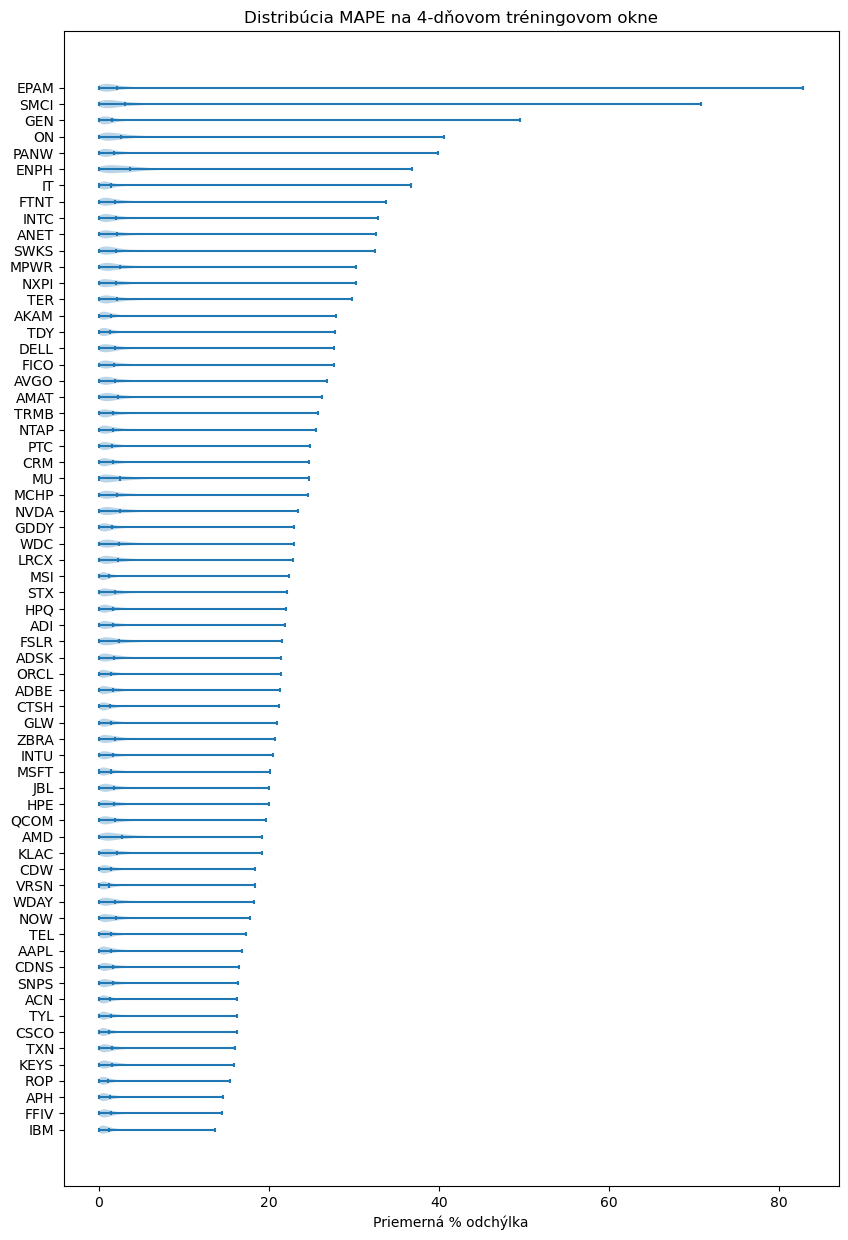

In [6]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [7]:
mean_performances

{'ROP': np.float64(1.109467941161698),
 'IBM': np.float64(1.1703311216872347),
 'CSCO': np.float64(1.2068499141217806),
 'MSI': np.float64(1.2095118341330982),
 'VRSN': np.float64(1.228440829909606),
 'ACN': np.float64(1.2607652049401281),
 'CTSH': np.float64(1.303411383197443),
 'APH': np.float64(1.3074250490426027),
 'TDY': np.float64(1.3124919313943573),
 'MSFT': np.float64(1.3626661911463394),
 'AKAM': np.float64(1.3641761273043034),
 'TEL': np.float64(1.3894977420279595),
 'TYL': np.float64(1.3912005179263842),
 'ORCL': np.float64(1.3998463878263374),
 'FFIV': np.float64(1.404966500527441),
 'IT': np.float64(1.4142071175336777),
 'CDW': np.float64(1.4443056378214711),
 'GLW': np.float64(1.467753371326436),
 'AAPL': np.float64(1.4750151460117387),
 'GEN': np.float64(1.487607340879874),
 'KEYS': np.float64(1.5490141419331387),
 'TXN': np.float64(1.5650361625416338),
 'GDDY': np.float64(1.5659563279856707),
 'PTC': np.float64(1.5901407722498038),
 'INTU': np.float64(1.627867049352319

In [8]:
np.mean([np.mean(i) for i in performance_simple.values()])

np.float64(0.4414159701090096)

# **Date-wise model dominance over naive**

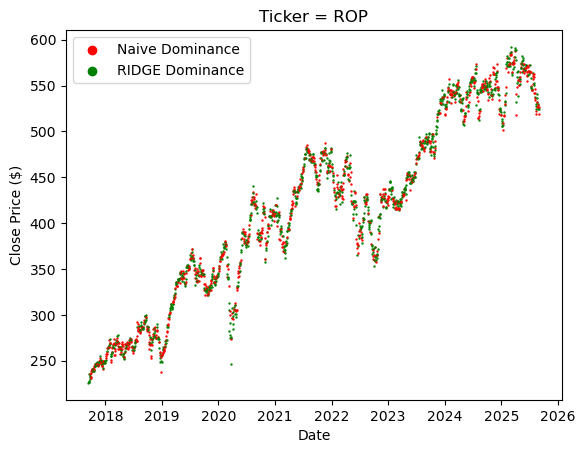

In [9]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ROP"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="red", s=0.5)
    else:
        plt.scatter(date, close_price, c="green", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

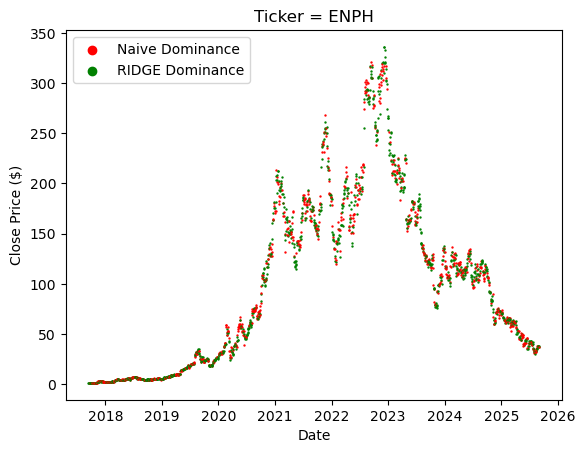

In [10]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ENPH"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="red", s=0.5)
    else:
        plt.scatter(date, close_price, c="green", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

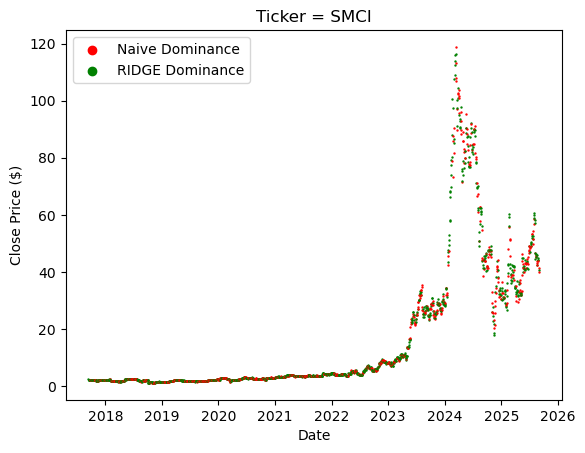

In [11]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "SMCI"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="red", s=0.5)
    else:
        plt.scatter(date, close_price, c="green", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

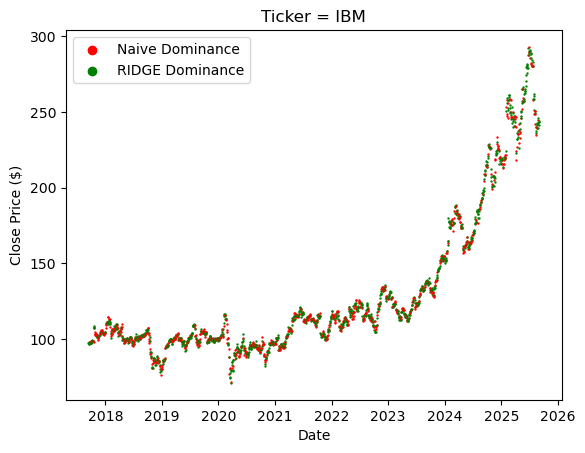

In [12]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "IBM"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="red", s=0.5)
    else:
        plt.scatter(date, close_price, c="green", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()